In [ ]:
#Lets have matplotlib "inline"
%matplotlib inline

#Import packages we need
import numpy as np
import gc
from matplotlib import animation, rc
from matplotlib import pyplot as plt
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
#import mpld3

import miscPlotting

try:
    from StringIO import StringIO
except ImportError:
    from io import StringIO

from common_simulator import *


# matplotlib global options here:
# usetex=True
# bbox tight
# text.size, figure.size

In [ ]:
simulators = [LxF.LxF, FORCE.FORCE, HLL.HLL, HLL2.HLL2, KP07.KP07, KP07_dimsplit.KP07_dimsplit, WAF.WAF]

In [ ]:
# ic can be bump, dambreak, or constant. Pass through papermill with `-p ic bump`
ic:str = 'dambreak'


In [ ]:
# Parameters
ic = "bump"


In [ ]:
print(f'ic = {ic}')

ic = bump


In [ ]:
simulators = [LxF.LxF, FORCE.FORCE, HLL.HLL, HLL2.HLL2, KP07.KP07, KP07_dimsplit.KP07_dimsplit, WAF.WAF]
domain_sizes = np.loadtxt('domain_sizes.csv').transpose().astype(int)
ref_file_size = domain_sizes[-1]
domain_sizes = domain_sizes[:-1]
ref_file = lambda simulator: gen_filename(None,
                     nx=ref_file_size[0],
                     ny=ref_file_size[1],
                     prefix="space", ic=ic, simulator=simulator.__name__)

# Run the simulators

In [ ]:
# Space calculations
'''
for simulator in simulators:
    commands = 'python calculator_simulator.py'.split(' ')
    commands += ['space']
    commands += [ic]
    commands += [simulator.__name__]
    commands += ['--ref', f'{ref_file(simulator)}']
    commands += ['--sizes']
    commands += [f'{nx}_{ny}' for nx,ny in domain_sizes]
    subprocess.run(commands).check_returncode()
'''
# Time calculations
'''
for simulator in simulators:
    commands = 'python calculator_simulator.py'.split(' ')
    commands += ['time']
    commands += [ic]
    commands += [simulator.__name__]
    commands += ['--sizes']
    commands += [f'{nx}_{ny}' for nx,ny in domain_sizes]
    subprocess.run(commands, check=True)
'''

"\nfor simulator in simulators:\n    commands = 'python calculator_simulator.py'.split(' ')\n    commands += ['time']\n    commands += [ic]\n    commands += [simulator.__name__]\n    commands += ['--sizes']\n    commands += [f'{nx}_{ny}' for nx,ny in domain_sizes]\n    subprocess.run(commands, check=True)\n"

## Load data

In [ ]:
time_ds_x, time_ds_y = [], []
space_ds_x, space_ds_y = [], []
megacells_per_sec = []
peak_megacells_per_sec = np.zeros(len(simulators))
sim_errors = []
sim_cons = []
sim_nt = []
longsim_nt = []
sim_tf = []
longsim_tf = []
longsim_elapsed_time = []

for  i, simulator in enumerate(simulators):
    # time data
    filename = gen_results_filename('time', simulator.__name__, ic)
    with np.load(filename) as d:
        order = np.argsort(d['ds_x'])
        time_ds_x.append(d['ds_x'][order])
        time_ds_y.append(d['ds_y'][order])
        megacells_per_sec.append(d['megacells_per_sec'][order])
        peak_megacells_per_sec[i] = d['peak_megacells_per_sec']
        longsim_nt.append(d['sim_nt'])
        longsim_tf.append(d['sim_tf'][order])
        longsim_elapsed_time.append(d['longsim_elapsed_time'][order])

    # space data
    filename = gen_results_filename('space', simulator.__name__, ic)
    with np.load(filename) as d:
        order = np.argsort(d['ds_x'])
        space_ds_x.append(d['ds_x'][order])
        space_ds_y.append(d['ds_y'][order])
        sim_errors.append(d['sim_errors'][order])
        sim_cons.append(d['sim_cons'][order])
        sim_nt.append(d['sim_nt'][order])
        sim_tf.append(d['sim_tf'])

# Reduce orders for redundant data
time_ds_x = np.array(time_ds_x)
time_ds_y = np.array(time_ds_y)
space_ds_x = np.array(space_ds_x)
space_ds_y = np.array(space_ds_y)
assert np.all(time_ds_x == space_ds_x) 
assert np.all(time_ds_y == space_ds_y) 

assert np.all(time_ds_x == time_ds_x[0]) 
#assert np.all(time_ds_y == time_ds_y[0]) 
ds_x = time_ds_x#[0]
ds_y = time_ds_y#[0]


megacells_per_sec = np.array(megacells_per_sec)
sim_errors = np.array(sim_errors)
sim_cons = np.array(sim_cons)
sim_nt = np.array(sim_nt)
longsim_tf = np.array(longsim_tf)

assert np.all(sim_tf == sim_tf[0])
sim_tf = sim_tf[0]
assert np.all(longsim_nt == longsim_nt[0])
longsim_nt = longsim_nt[0]

gc.collect()

649

# Initial condition

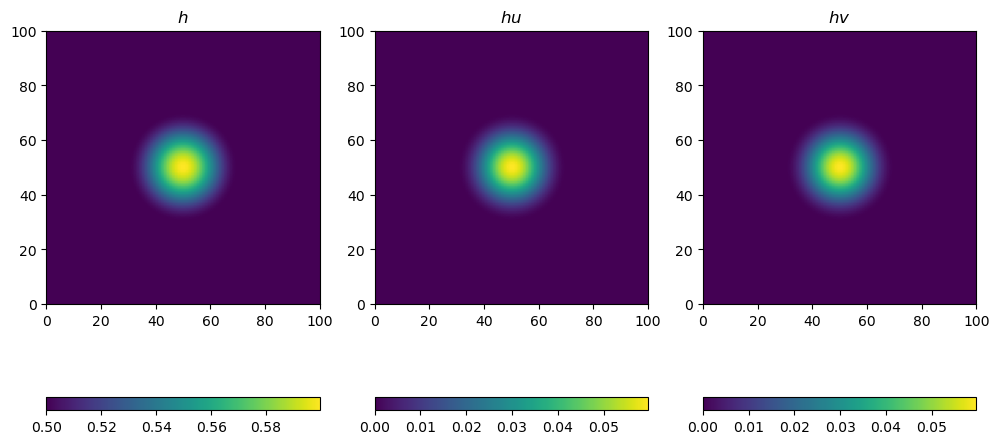

In [ ]:
width = 50
height = width
bump_size = 10
nx = ny = 100
test_data_args = {
            'nx': nx,
            'ny': ny,
            'ref_nx': 1000,
            'ref_ny': 1000,
            'num_ghost_cells': GetSimulator.num_ghost_cells[simulator.__name__]
}
# This will change according to the init
test_data_args.update(GetInitialCondition.ics[ic]['test_data_args'])
h, hu, hv, dx, dy, = GetInitialCondition.ics[ic]['fn'](**test_data_args)

fig = plt.figure()
ax=plt.subplot(1,3,1)
im=plt.imshow(h, extent=[0, nx*dx, 0, ny*dy])
plt.title("$h$")
plt.colorbar(orientation='horizontal')

ax=plt.subplot(1,3,2)
im=plt.imshow(hu, extent=[0, nx*dx, 0, ny*dy])
plt.title("$hu$")
plt.colorbar(orientation='horizontal')

ax=plt.subplot(1,3,3)
im=plt.imshow(hv, extent=[0, nx*dx, 0, ny*dy])
plt.title("$hv$")
plt.colorbar(orientation='horizontal')

miscPlotting.save_figure(fig, "ic", ic)

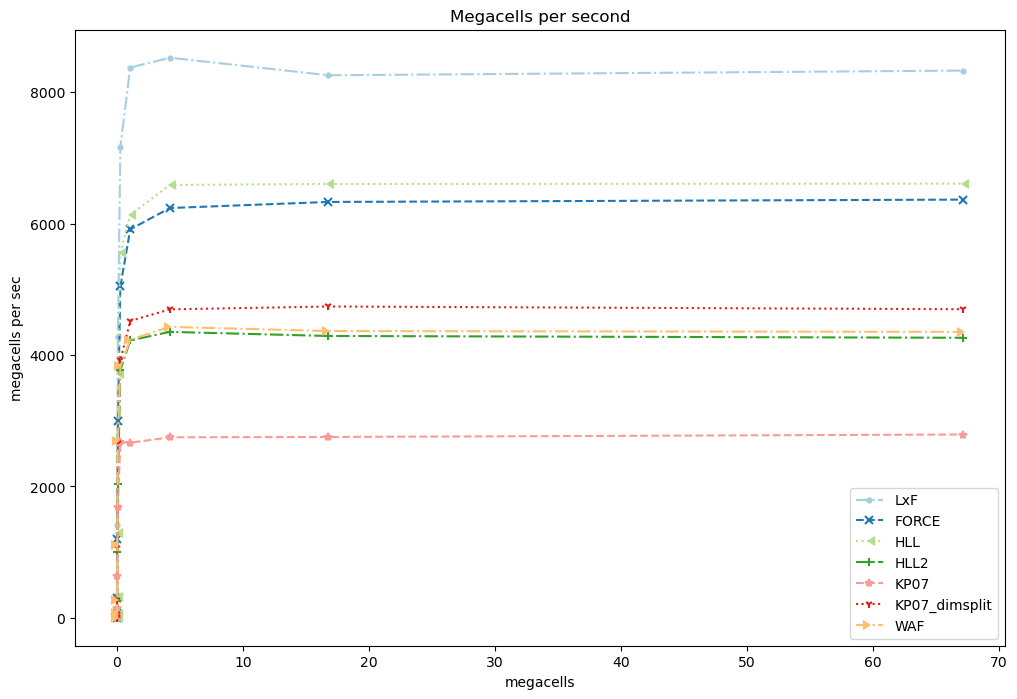

In [ ]:
fig = plt.figure()

miscPlotting.setBwStyles(fig.gca())
for i, simulator in enumerate(simulators):
    plt.plot(ds_x[i] * ds_y[i] * 10**-6, megacells_per_sec[i], label = simulator.__name__)
    plt.xlabel("megacells")
    plt.ylabel("megacells per sec")
plt.legend()
plt.title("Megacells per second")
miscPlotting.save_figure(fig, "megacells_per_second", ic)

0 <class 'GPUSimulators.LxF.LxF'> 8371.44792395216
1 <class 'GPUSimulators.FORCE.FORCE'> 6311.59026648577
2 <class 'GPUSimulators.HLL.HLL'> 6600.899200312347
3 <class 'GPUSimulators.HLL2.HLL2'> 4302.3123896713005
4 <class 'GPUSimulators.KP07.KP07'> 2764.183598331818
5 <class 'GPUSimulators.KP07_dimsplit.KP07_dimsplit'> 4710.893634162148
6 <class 'GPUSimulators.WAF.WAF'> 4382.599810907576


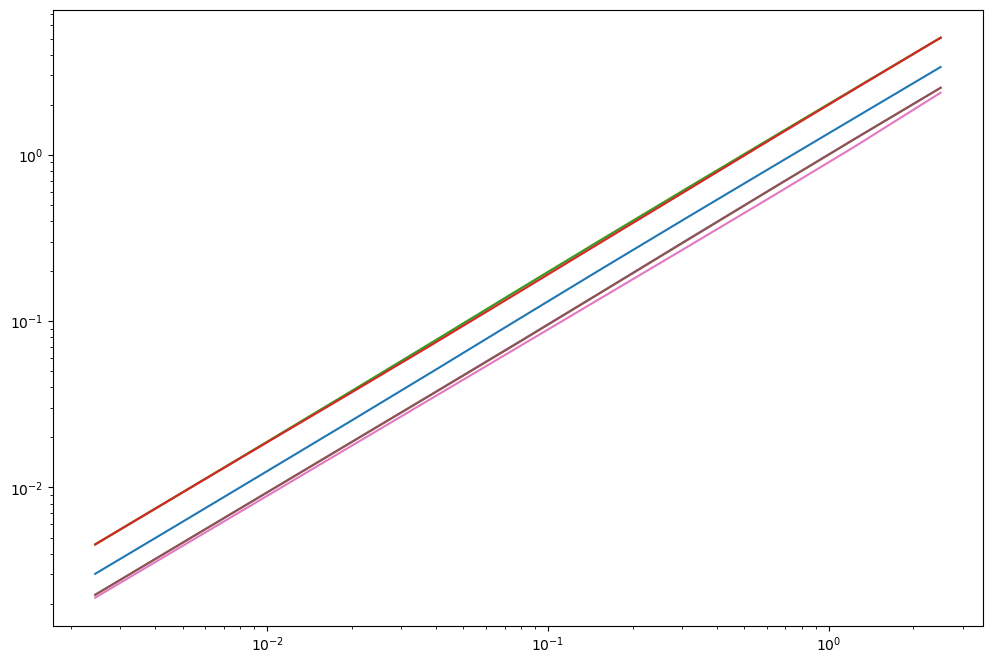

In [ ]:
longsim_average_dt = longsim_tf / longsim_nt
sim_average_dt = sim_tf / sim_nt
for i, simulator in enumerate(simulators):
    print(i, simulator, peak_megacells_per_sec[i])
    plt.loglog(20/ds_x[i], longsim_average_dt[i])

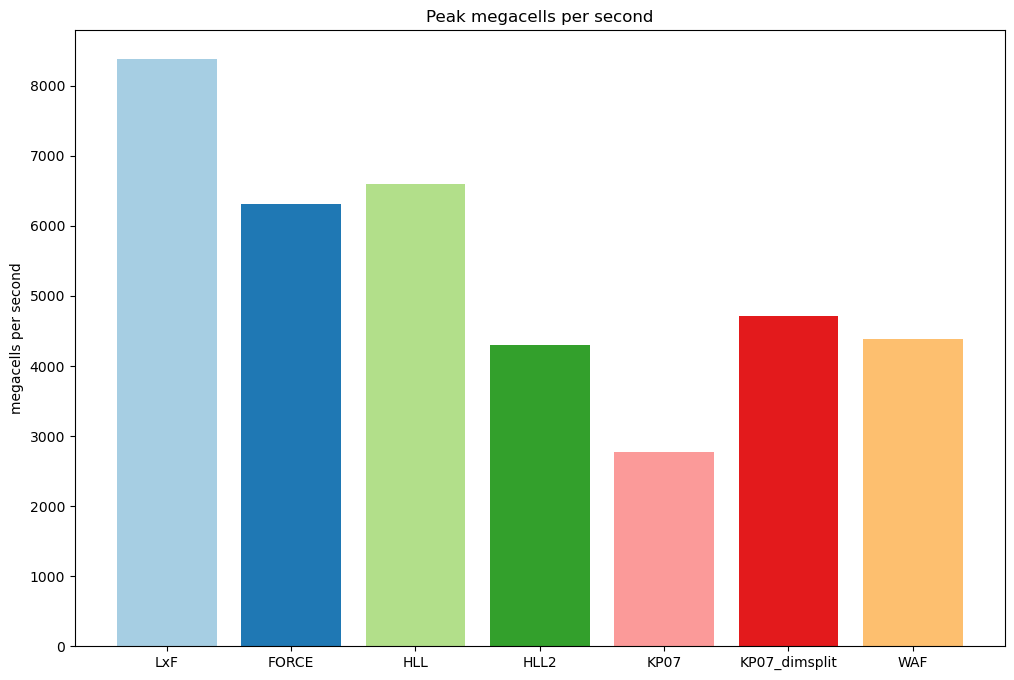

In [ ]:
import seaborn as sns
fig = plt.figure()
miscPlotting.setBwStyles(fig.gca())
plt.bar([sim.__name__ for sim in simulators], peak_megacells_per_sec, color=sns.color_palette("Paired", 7))
plt.ylabel("megacells per second")
plt.title("Peak megacells per second")
miscPlotting.save_figure(fig, "peak_megacells_per_second", ic)

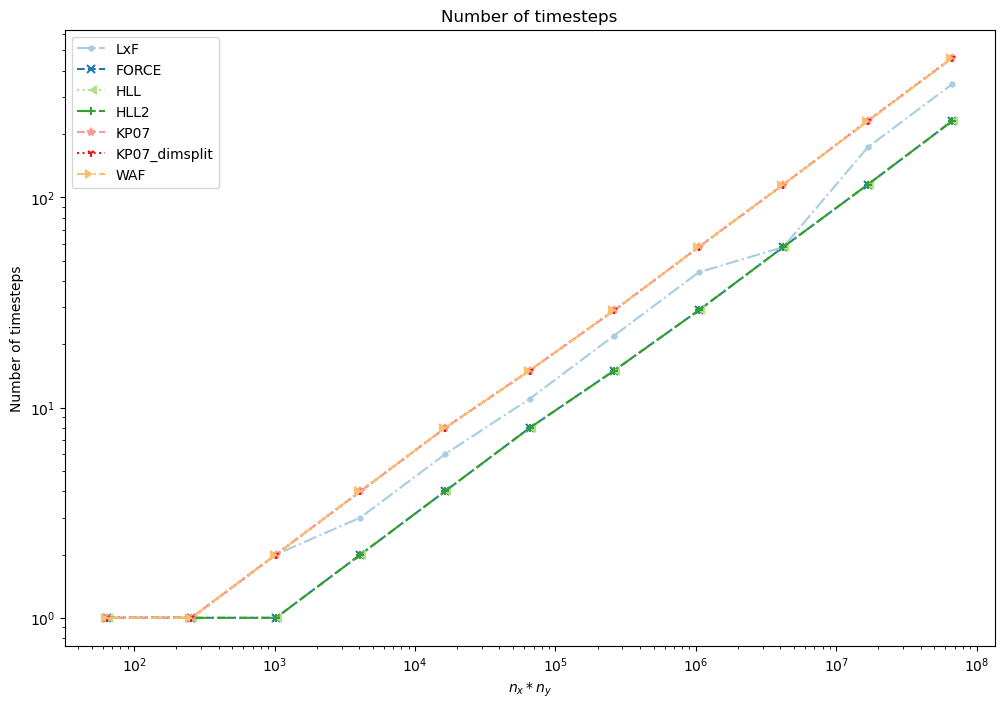

In [ ]:
fig = plt.figure()

miscPlotting.setBwStyles(fig.gca())
for i, simulator in enumerate(simulators):
    plt.loglog(ds_x[i] * ds_y[i], sim_nt[i], label = simulator.__name__)
    plt.xlabel("$n_x * n_y$")
    plt.ylabel("Number of timesteps")
plt.legend()
plt.title("Number of timesteps")
miscPlotting.save_figure(fig, "number_of_timesteps", ic)

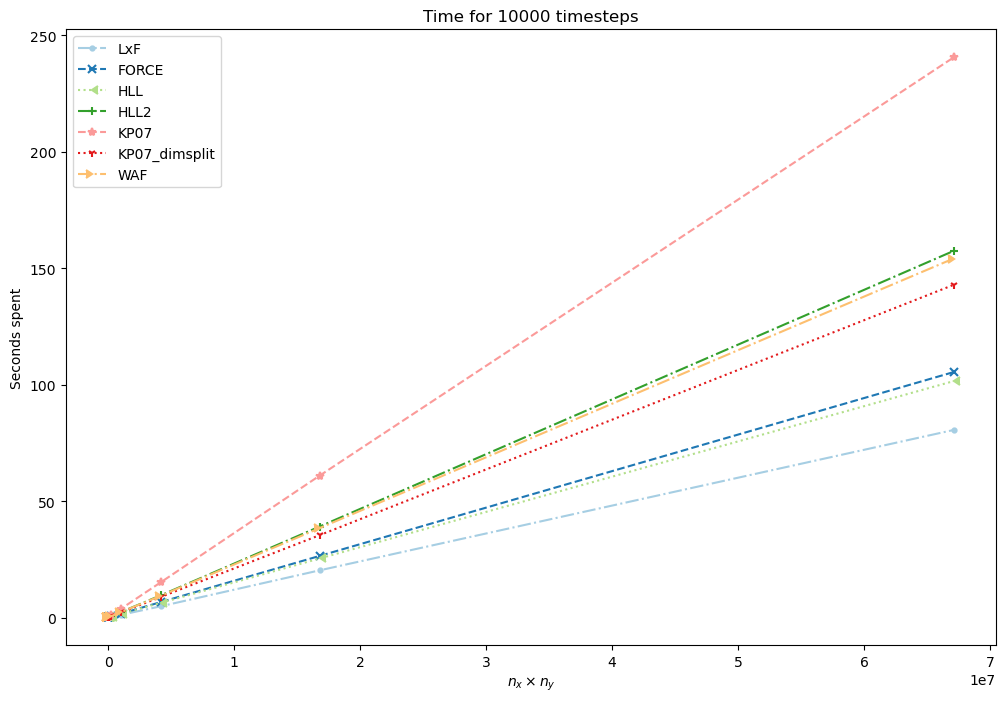

In [ ]:
fig = plt.figure()

miscPlotting.setBwStyles(fig.gca())
for i, simulator in enumerate(simulators):
    plt.plot(ds_x[i] * ds_y[i], longsim_elapsed_time[i], label = f"{simulator.__name__}")
    plt.xlabel("$n_x\\times n_y$")
    plt.ylabel("Seconds spent")
plt.legend()
plt.title(f"Time for {longsim_nt.astype(int)} timesteps")
miscPlotting.save_figure(fig, "time_spent_for_bignumber_timesteps", ic)

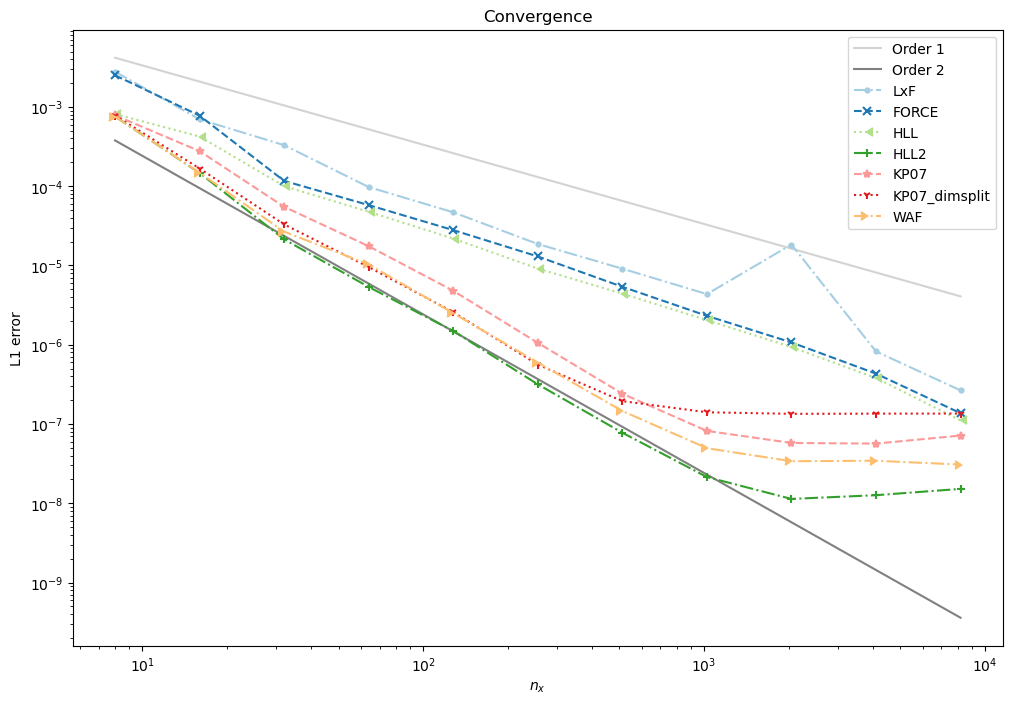

In [ ]:
fig = plt.figure()
x_axis_start = np.min(ds_x)
scaling = np.max(sim_errors[:,0]) * 1.5 * x_axis_start
plt.plot(ds_x[0], scaling / np.array(ds_x[0]), '-', c='lightgray', label='Order 1')
scaling = np.min(sim_errors[:,0]) * 0.5 * x_axis_start ** 2
plt.plot(ds_x[0], scaling / np.power(ds_x[0], 2), '-', c='gray', label='Order 2')

miscPlotting.setBwStyles(fig.gca())
for i, simulator in enumerate(simulators):
    plt.loglog(ds_x[i,:], sim_errors[i,:], label = simulator.__name__)
    plt.xlabel("$n_x$")
    plt.ylabel("L1 error")
plt.legend()
plt.title("Convergence")
miscPlotting.save_figure(fig, "convergence_rate", ic)

## Time vs absolute error plot

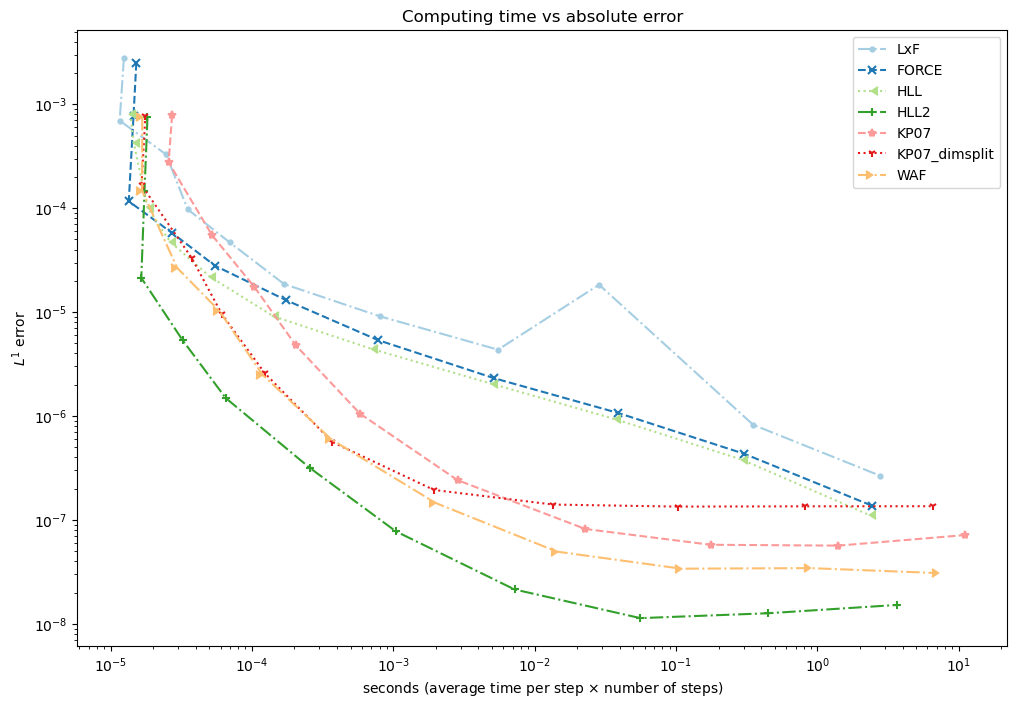

In [ ]:
# Plot the timing and error data
secs_per_timestep = longsim_elapsed_time / longsim_nt
fig = plt.figure()
miscPlotting.setBwStyles(fig.gca())
plt.title("Computing time vs absolute error")

for i, simulator in enumerate(simulators):
    plt.loglog(secs_per_timestep[i,:] * sim_nt[i,:], sim_errors[i,:], label = simulator.__name__)
    plt.ylabel("$L^1$ error")
    plt.xlabel("seconds (average time per step $\\times$ number of steps)")

plt.legend()
miscPlotting.save_figure(fig, "time_vs_absolute_error", ic)

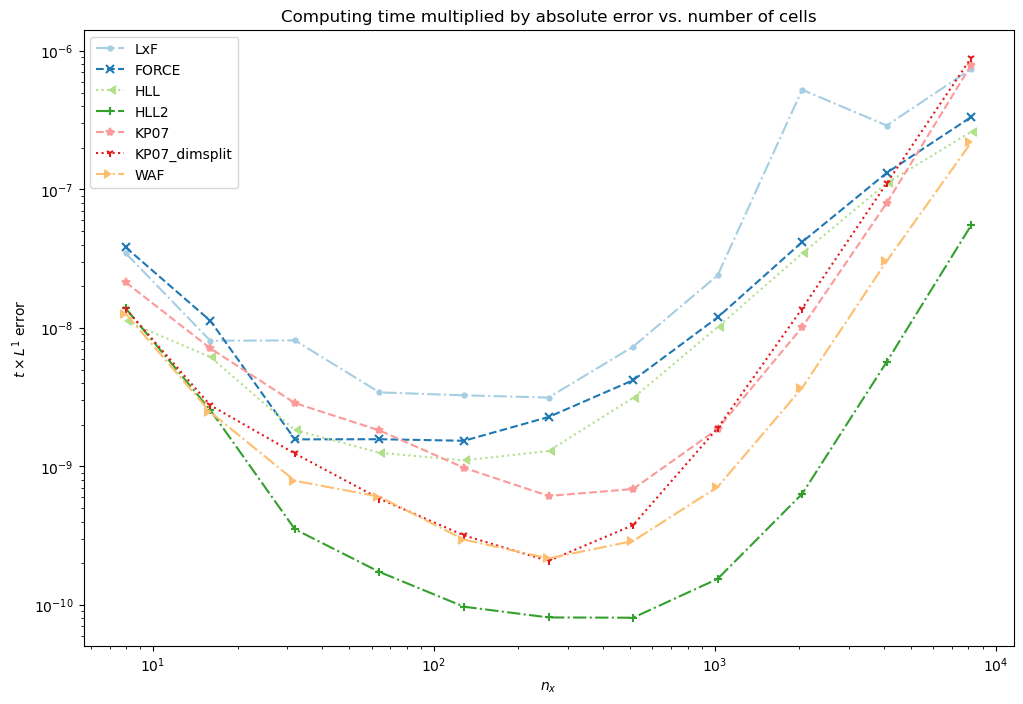

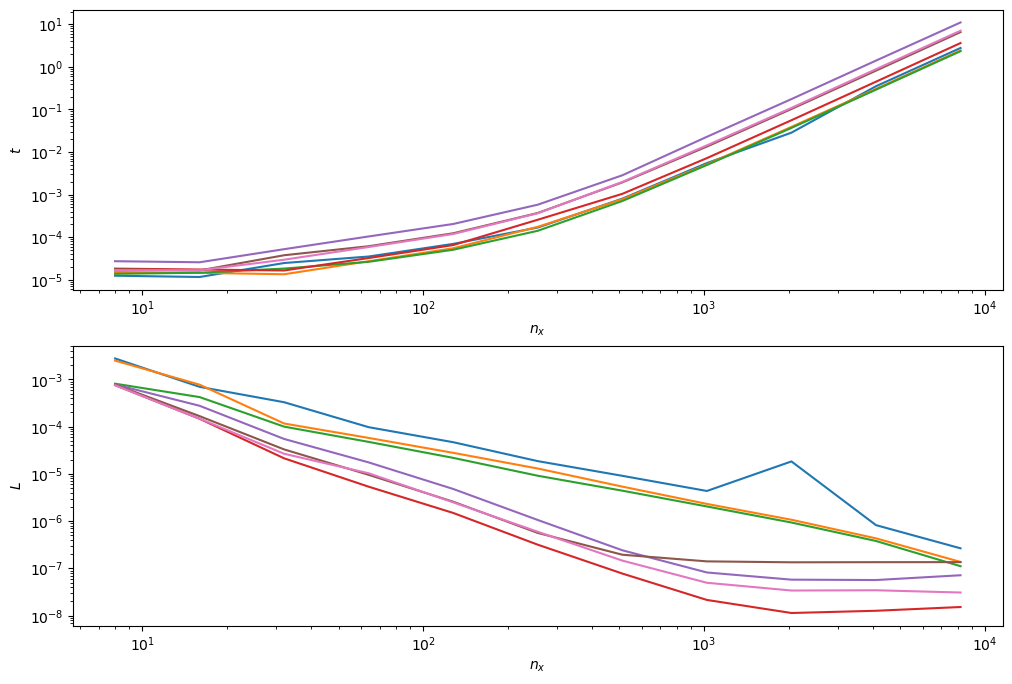

In [ ]:
# Plot of whether time or error wins as grids become smaller
secs_per_timestep = longsim_elapsed_time / longsim_nt
fig = plt.figure()
miscPlotting.setBwStyles(fig.gca())
plt.title("Computing time multiplied by absolute error vs. number of cells")

for i, simulator in enumerate(simulators):
    plt.loglog(ds_x[i,:], secs_per_timestep[i,:] * sim_nt[i,:] * sim_errors[i,:], label = simulator.__name__)
    plt.xlabel("$n_x$")
    plt.ylabel("$t \\times L^1$ error")

plt.legend()
miscPlotting.save_figure(fig, "t_times_absolute_error", ic)

fig, (ax1, ax2) = plt.subplots(2, sharex=False)
for i, simulator in enumerate(simulators):
    ax1.loglog(ds_x[i,:], secs_per_timestep[i,:] * sim_nt[i,:], label=simulator.__name__)
    ax2.loglog(ds_x[i,:], sim_errors[i,:], label=simulator.__name__)
    ax1.set_xlabel("$n_x$")
    ax1.set_ylabel("$t$")
    ax2.set_xlabel("$n_x$")
    ax2.set_ylabel("$L$")
miscPlotting.save_figure(fig, "t_and_absolute_error_subplots", ic)

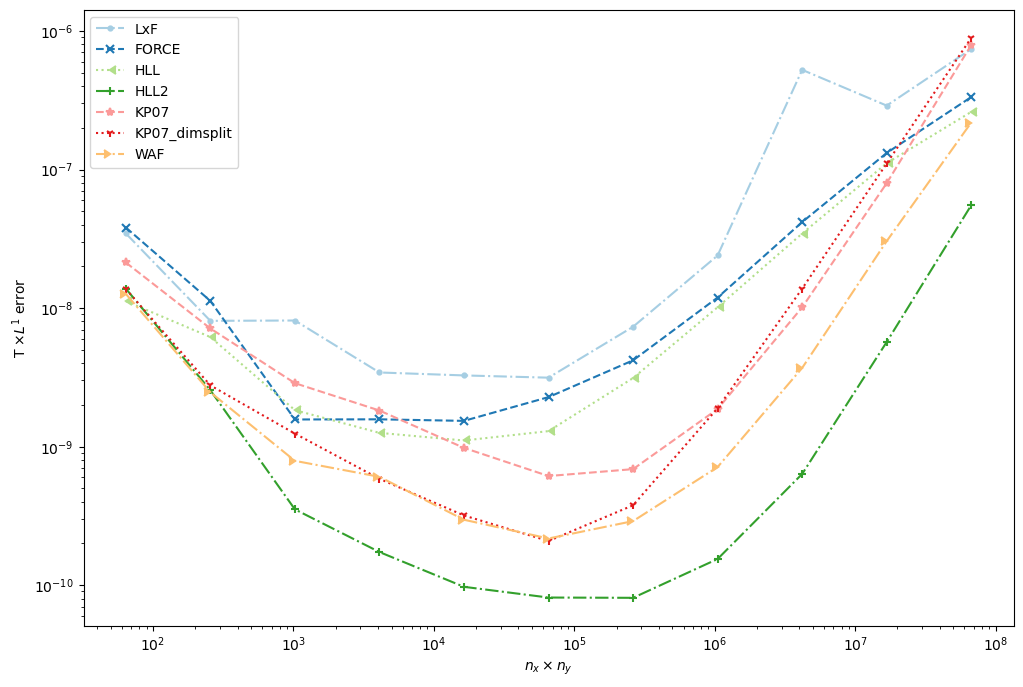

In [ ]:
# Plot error/time vs nx
fig = plt.figure()
miscPlotting.setBwStyles(fig.gca())
# plt.title("Computing time vs absolute error")

secs_per_timestep = longsim_elapsed_time / longsim_nt

for i, simulator in enumerate(simulators):
    plt.loglog(ds_x[i] * ds_y[i], secs_per_timestep[i,:] * sim_nt[i,:] * sim_errors[i,:], label = simulator.__name__)
plt.ylabel("T $\\times L^1$ error")
plt.xlabel("$n_x \\times n_y$")

plt.legend()
# miscPlotting.save_figure(fig, "time_to_solution", ic)

## Peak performance vs rate of convergence

,8.0,16.0,32.0,64.0,128.0,256.0,512.0,1024.0,2048.0,4096.0
LxF,1.997722,1.082225,1.754693,1.056727,1.330716,1.033022,1.066329,-2.078485,4.480605,1.630386
FORCE,1.693376,2.732566,1.013401,1.049348,1.103133,1.272039,1.216304,1.114251,1.307670,1.657566
HLL,0.943054,2.078052,1.073513,1.123619,1.257062,1.049705,1.110231,1.129366,1.297930,1.774922
HLL2,2.366323,2.781928,1.994947,1.846741,2.232847,2.028404,1.856557,0.917676,-0.156412,-0.264070
KP07,1.499801,2.333361,1.649717,1.868909,2.181097,2.129757,1.561064,0.504704,0.027053,-0.337180
KP07_dimsplit,2.220265,2.341675,1.787296,1.891200,2.195813,1.531243,0.467398,0.065532,-0.008651,-0.003488
WAF,2.355113,2.467694,1.372619,2.045723,2.067852,2.029060,1.557833,0.545898,-0.019161,0.159113


,Max,Min,Mean
LxF,4.480605,-2.078485,1.331633
FORCE,2.732566,1.013401,1.440024
HLL,2.078052,0.943054,1.233605
HLL2,2.781928,-0.264070,2.158250
KP07,2.333361,-0.337180,1.889101
KP07_dimsplit,2.341675,-0.008651,1.776413
WAF,2.467694,-0.019161,1.985128


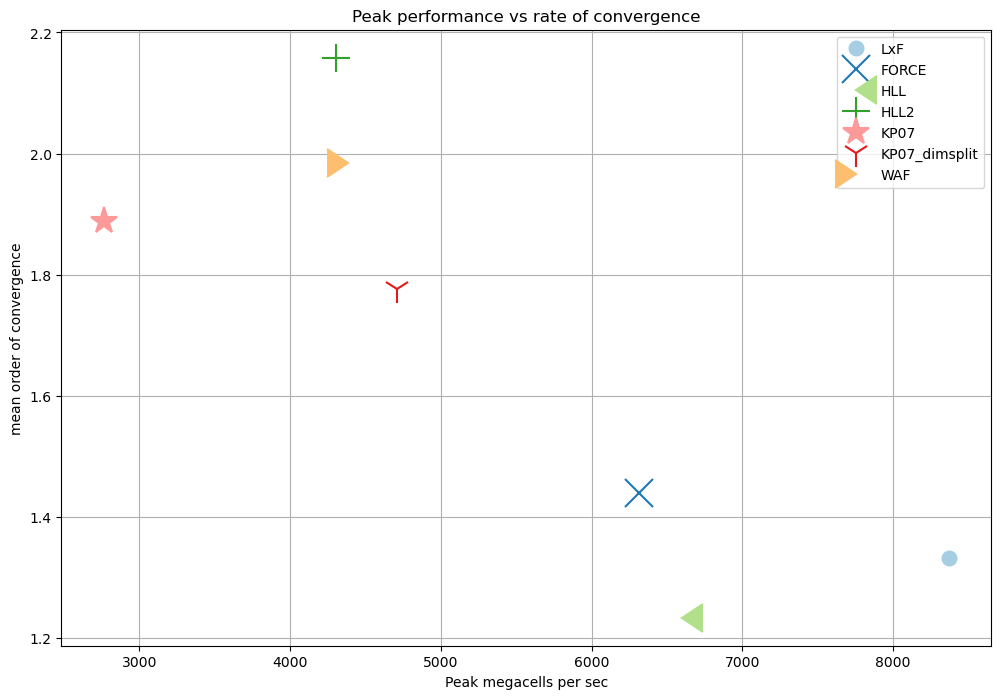

In [ ]:
order = np.zeros((ds_x.shape[0], ds_x.shape[1]-1))
for i, sim in enumerate(simulators):
    order[i, :] = np.log2(sim_errors[i,:-1]/sim_errors[i,1:])

fig = plt.figure()
miscPlotting.setBwStyles(fig.gca())
plt.title("Peak performance vs rate of convergence")
for i, sim in enumerate(simulators):
    plt.plot(peak_megacells_per_sec[i], np.mean(order[i,:-3]), label=sim.__name__, markersize=20, linewidth=1e-5)#, color=sns.color_palette("Paired", 8)[i])
plt.xlabel("Peak megacells per sec")
plt.ylabel("mean order of convergence")
plt.grid()
plt.legend()

import pandas as pd
from IPython.display import display
table = pd.DataFrame(order, columns=ds_x[0,:-1], index=[simulator.__name__ for simulator in simulators])
display(table)

order_summary = pd.DataFrame(np.empty((len(simulators), 3)), columns=['Max', 'Min', 'Mean'], index=[simulator.__name__ for simulator in simulators])
for i, simulator in enumerate(simulators):
    order_summary.loc[simulator.__name__] = [np.max(order[i,:]), 
        np.min(order[i,:]), 
        np.mean(order[i,:-3])]
display(order_summary)

miscPlotting.save_figure(fig, "peak_perf_vs_convergence_rate", ic)

## Solution plots

In [ ]:
def plot_solution(simulator, nx, ny, label, **kwargs):
    datafilename = gen_filename(None, nx, ny, ic=ic, simulator=simulator.__name__, prefix='space')
    
    #Read the solution
    with np.load(datafilename) as data:
        h = data['h']
        
    x = np.linspace(0.5, nx-0.5, nx)*10.0/float(nx)
    y = h[int(h.shape[0]/2),:]
    
    plt.plot(x, y, label=label, **kwargs)
    
    h = None
    x = None
    gc.collect() # Force 

def plot_reference(simulator, label="Reference", **kwargs):
    if ic == 'dambreak':
        ref_x, ref_h, _ = miscPlotting.gen_reference(4096)
        plt.plot(ref_x, ref_h, label=label, **kwargs)
    else:
        plot_solution(simulator, ref_file_size[0], ref_file_size[1], label=label, **kwargs)


In [ ]:
def plot_comparison(**kwargs):
    ref_x, ref_h, _ = miscPlotting.gen_reference(4096)
    plt.plot(ref_x, ref_h, '-', color='black', label='Analytic')
    ref_x = None
    ref_h = None
    gc.collect()

    for i, simulator in enumerate(simulators):
        NX = 512
        plot_solution(simulator, NX, NX, label=simulator.__name__, **kwargs)
        

if ic == 'dambreak':
    fig = plt.figure()
    miscPlotting.setBwStyles(fig.gca())

    boxes = np.array([\
            [[3.5, 4.1], [0.0044, 0.00505]], \
            [[4.7, 5.05], [0.0025, 0.0027]],  \
            [[6.1, 6.40], [0.0009, 0.0026]] \
            ])

    plot_comparison(marker=' ')
    for box_x, box_y in boxes:
        x = np.kron(box_x, np.ones((2)))
        y = np.hstack((box_y, box_y[::-1]))
        fig.gca().fill(x, y, fill=True, linestyle='-', color='gray', alpha=0.5)
    plt.xlim([0, 10])
    plt.ylim([0, 0.0055])
    plt.legend(loc='lower left')
    # miscPlotting.save_figure(fig, 'solution', ic)

    for i, bbox in enumerate(boxes):
        fig = plt.figure()
        miscPlotting.setBwStyles(fig.gca())
        plot_comparison()
        plt.xlim(bbox[0])
        plt.ylim(bbox[1])
        plt.legend()
        
        miscPlotting.save_figure(fig, "solution_zoom_" + str(i), ic)

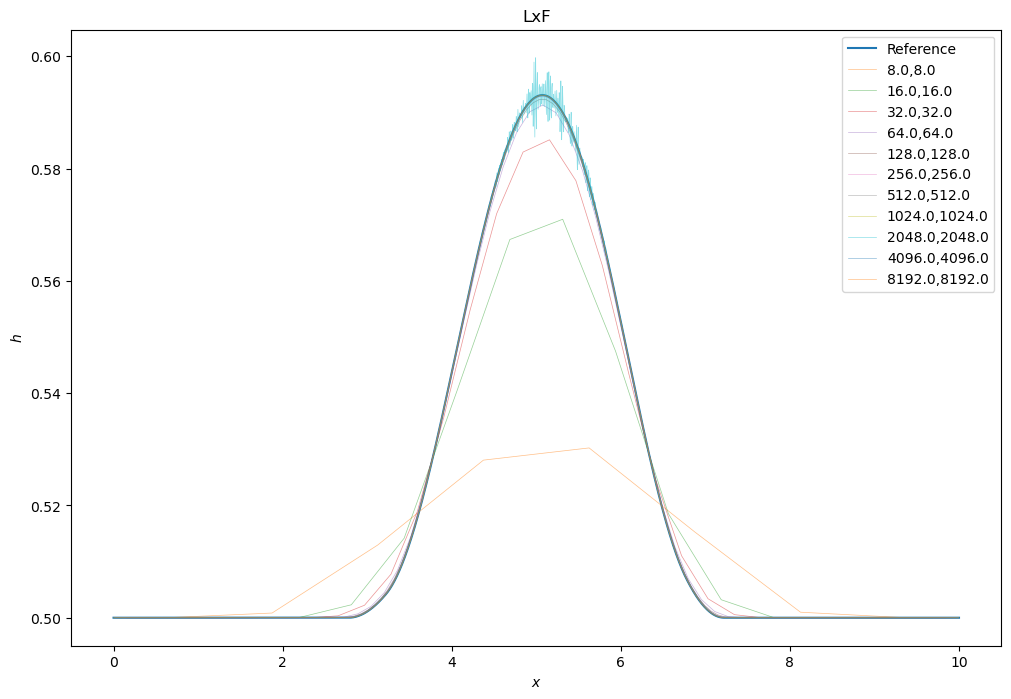

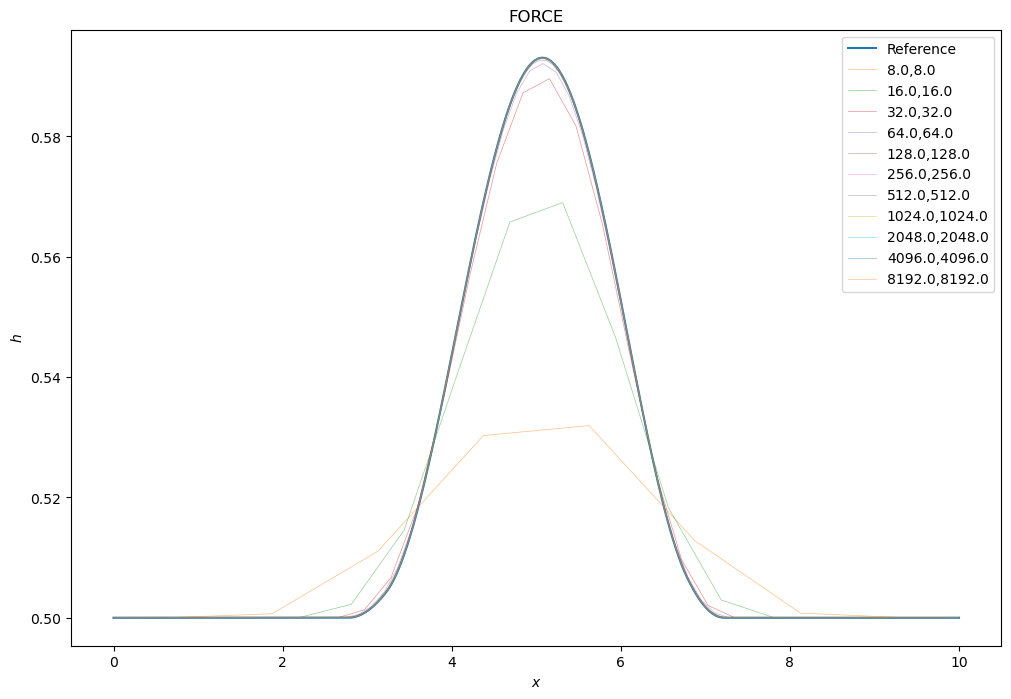

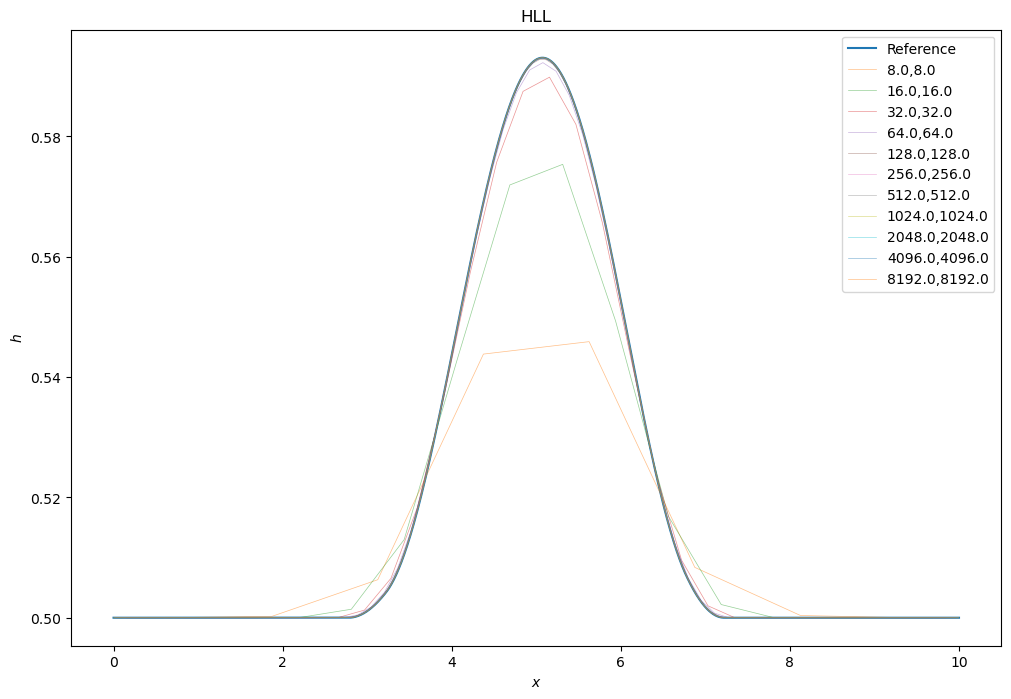

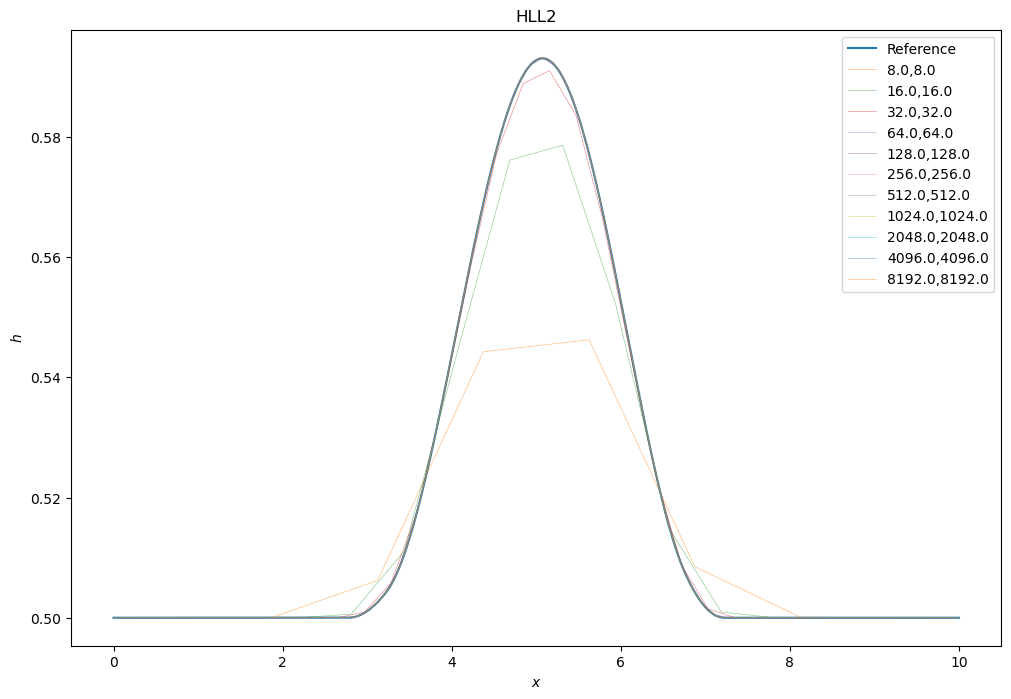

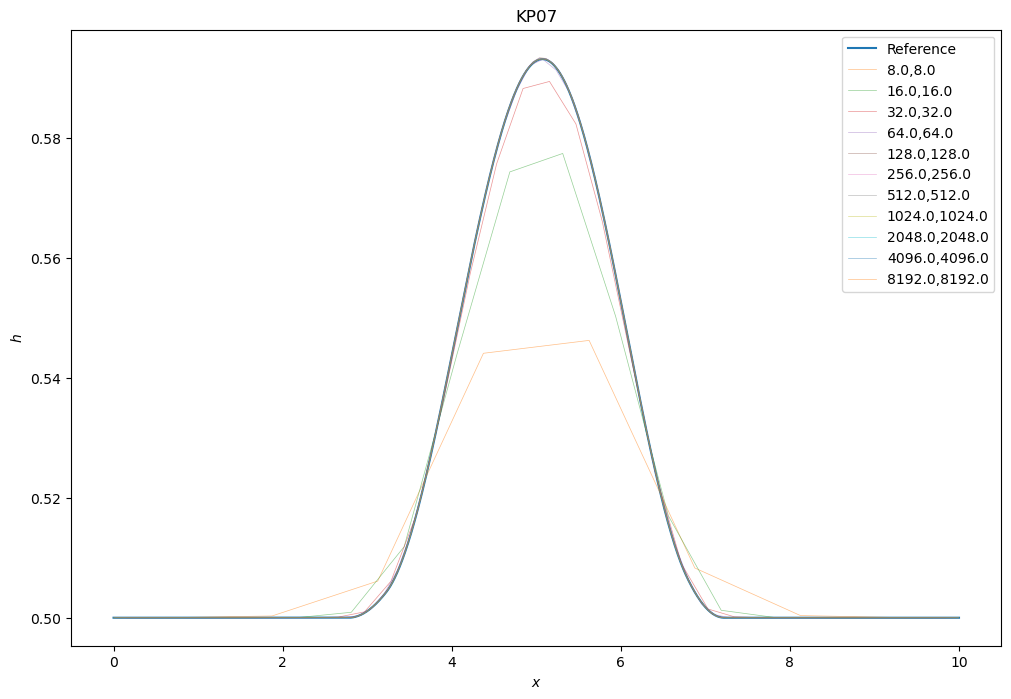

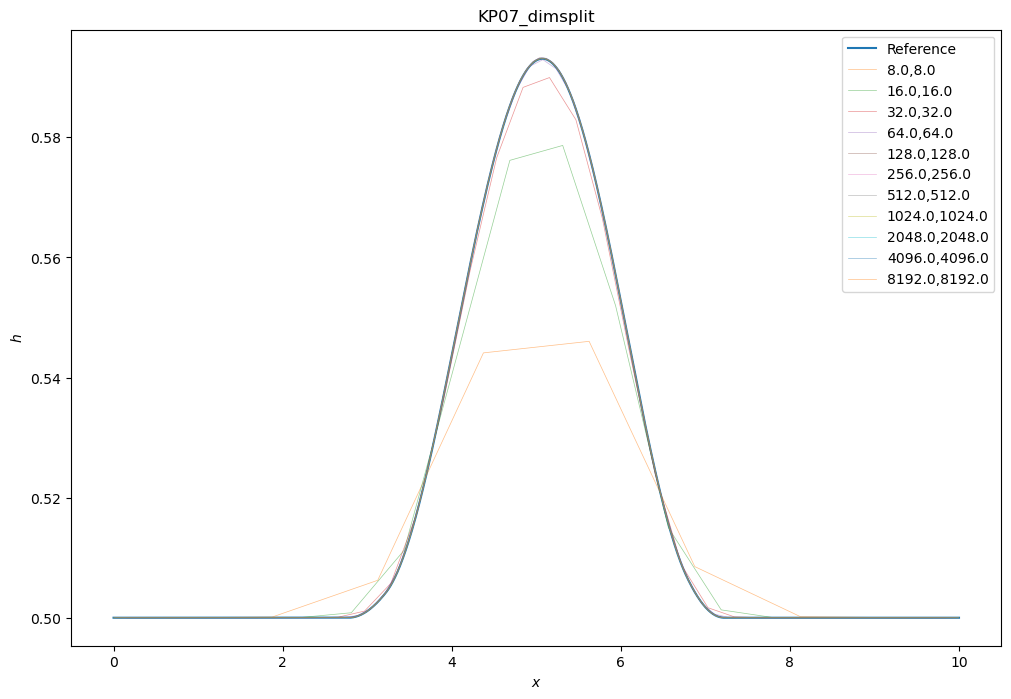

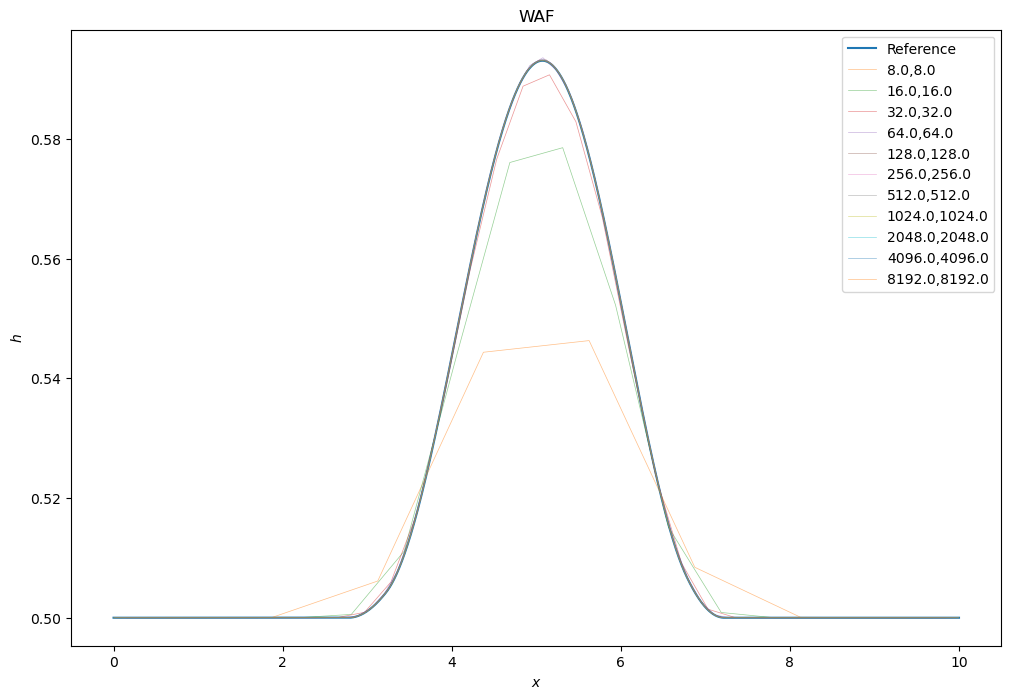

In [ ]:

for i, simulator in enumerate(simulators):
    fig = plt.figure()
    # miscPlotting.setBwStyles(fig.gca())
#    plot_solution(simulator, ref_nx, label=str(ref_nx) +" (ref)", c='k', ls='dotted', marker=None, lw=1, alpha=0.5)
    plot_reference(simulator)
    for nx,ny in zip(ds_x[i], ds_y[i]):
#        fig.set_prop_cycle(cycler('color', miscPlotting.sns.color_palette()))
        plot_solution(simulator, nx.astype(int), ny.astype(int), label=str(nx) + ',' + str(ny), marker=None, lw=0.5, alpha=0.5)
    plt.xlabel("$x$")
    plt.ylabel("$h$")
    plt.legend()
    plt.title(simulator.__name__)
    miscPlotting.save_figure(fig, f"solutions_{simulator.__name__}", ic)